<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Desafio 3 PLN CEIA Ojeda, Juan
## Modelo de lenguaje con tokenización por caracteres


## Tokenización, modelado y predicciones

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import pad_sequences # se utilizará para padding
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Input, Masking, Embedding

from tensorflow.keras.losses import SparseCategoricalCrossentropy

## Datos

Se emplea el libro "Las crónicas de Narnia: El león, la bruja y el ropero" preprocesado previamente.

Cada linea del archivo es una oración. Esta elección es para mejorar la generación de nuevas secuencias a través del contexto de una oración completa.

In [3]:
# Defino la ruta del archivo
file_path = os.path.join('texto_las-cronicas-de-narnia-el-leon-la-bruja-y-el-ropero_oraciones.txt')
# Leer el contenido del archivo
with open(file_path, 'r', encoding='utf-8') as file:
    file_content = file.read()
# Pasar todo el texto a minúscula
article_text = file_content.lower()
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'las crónicas de narnia:    el leon, la bruja       y el ropero                                             capítulo 1                        lucía investiga en el ropero        había una vez cuatro niños cuyos nombres eran pedro, susana, edmundo y lucía.\nesta historia relata lo que les sucedió cuando, durante la guerra y a causa de los bombardeos, fueron enviados lejos de londres a la casa de un viejo profesor.\néste vivía en medio del campo, a diez millas de la estación más cercana y a dos millas del correo más próximo.\nel profesor no era casado, así es que un ama de llaves, la señora macready, y tres sirvientas atendían su casa. (las sirvientas se llamaban ivy, margarita y betty, pero ellas no intervienen mucho en esta historia.)    el anciano profesor tenía un aspecto curioso, pues su cabello blanco no sólo le cubría la cabeza sino también casi toda la cara.\nlos niños simpatizaron con él al instante, a pesar que lucía, la menor, sintió miedo al verlo por primera vez, y edmundo, 

## Elegir el tamaño del contexto
En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus de texto puede ser considerado un documento en sí mismo y el tamaño de contexto puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.    

In [4]:
# seleccionamos el tamaño de contexto
max_context_size = 100
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)
# la longitud de vocabulario de caracteres es:
print(f'Longitud del vocabulario de caracteres: {len(chars_vocab)}')

Longitud del vocabulario de caracteres: 57


In [5]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

## Tokenizar

In [6]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]
tokenized_text[:10]

[34, 7, 22, 3, 38, 24, 19, 30, 33, 38]

## Organización y estructuración del dataset

Se separa el dataset de entrenamiento y validación.
`p_val` será la proporción del corpus que se reservará para validación
`num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación

In [7]:
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el $N+1$).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

In [8]:
X.shape

(189871, 100)

In [9]:
X[0,:10]

array([34,  7, 22,  3, 38, 24, 19, 30, 33, 38])

In [10]:
y[0,:10]

array([ 7, 22,  3, 38, 24, 19, 30, 33, 38,  7])

In [11]:
vocab_size = len(chars_vocab)

## Definir el modelo

In [12]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
model = Sequential(name="modelo_narnia_LSTM")

# Entrada explícita
model.add(Input(shape=(None,), name="input_secuencia"))

# Opcional, ignora el padding (si 0 es el token reservado para padding)
#model.add(Masking(mask_value=0, name="masking"))

# Embedding entrenable
model.add(Embedding(input_dim=vocab_size + 1, output_dim=50, name="embedding"))

# Dos capas LSTM apiladas con dropout
model.add(LSTM(100, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, name="lstm_1"))
model.add(LSTM(100, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, name="lstm_2"))

# Capa de salida con softmax
model.add(Dense(vocab_size + 1, activation='softmax', name="salida"))

# Compilación del modelo
model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer='rmsprop'
)

model.summary()

Model: "modelo_narnia_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 50)          2900      
                                                                 
 lstm_1 (LSTM)               (None, None, 100)         60400     
                                                                 
 lstm_2 (LSTM)               (None, None, 100)         80400     
                                                                 
 salida (Dense)              (None, None, 58)          5858      
                                                                 
Total params: 149,558
Trainable params: 149,558
Non-trainable params: 0
_________________________________________________________________


In [14]:
import tensorflow as tf

# Ver dispositivos físicos disponibles
print("Dispositivos detectados:")
for device in tf.config.list_physical_devices():
    print(device)


Dispositivos detectados:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [15]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


## Entrenamiento

In [16]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=512)

Epoch 1/20
371/371 [==============================] - ETA: 0s - loss: 2.7063
 mean perplexity: 10.341134757669542 

Saved new model!
371/371 [==============================] - 753s 2s/step - loss: 2.7063
Epoch 2/20
371/371 [==============================] - ETA: 0s - loss: 2.1118
 mean perplexity: 8.185549464095237 

Saved new model!
371/371 [==============================] - 731s 2s/step - loss: 2.1118
Epoch 3/20
371/371 [==============================] - ETA: 0s - loss: 1.8778
 mean perplexity: 6.907357384910873 

Saved new model!
371/371 [==============================] - 786s 2s/step - loss: 1.8778
Epoch 4/20
371/371 [==============================] - ETA: 0s - loss: 1.7189
 mean perplexity: 6.424639365089453 

Saved new model!
371/371 [==============================] - 771s 2s/step - loss: 1.7189
Epoch 5/20
371/371 [==============================] - ETA: 0s - loss: 1.6170
 mean perplexity: 6.144962276317366 

Saved new model!
371/371 [==============================] - 793s 2s/step

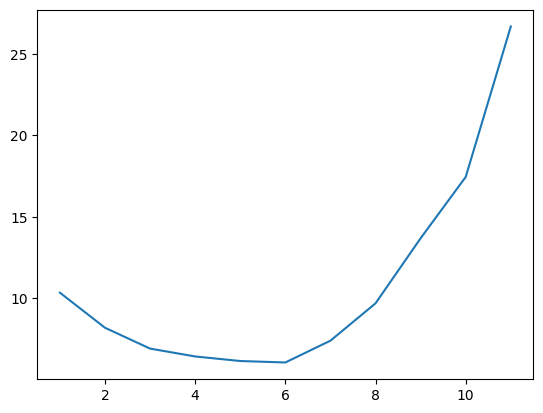

In [17]:
# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

## Generación de secuencias

In [18]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [19]:
input_text='Tumnus'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'Tumnus que estaba el castor de la ca'

## Beam search y muestreo aleatorio

In [20]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [21]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=0.1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens

In [22]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=0.1, mode='det')

In [23]:
salidas[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22, 19, 34, 46,  3,
        1, 30,  3,  1, 34,  3, 53, 46, 53,  1, 30, 35, 46,  3,  1, 30,  3,
       49, 32,  1,  3,  1, 22, 35, 32,  9, 33,  1, 24, 46, 30,  3,  1, 30,
        3,  1, 34,  3, 38,  7, 22, 35, 46, 24,  3, 45,  1,  3, 34,  7,  3,
       55, 24, 32, 15,  7,  3, 55, 34,  7, 30, 38,  7, 50,  3,  3,  3,  3,
       14,  8, 46,  0,  6,  3, 14, 45, 33, 15, 46,  3, 34, 32, 38, 44,  7,
       50,  3,  3,  3,  3,  3, 14])

In [24]:
# veamos las salidas
print(decode(salidas[0]))

hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhsólo en el momento en que estuvieron en el castor de la bruja blanca.    —¡oh! —dijo lucía.     —


In [25]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=0.1, mode='sto')

In [26]:
# veamos las salidas
print(decode(salidas[0]))

hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhsólo en el momento en que estuvieron a la bruja blanca de la bruja blanca de la bruja blanca de l


In [27]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=1, mode='sto')

In [28]:
# veamos las salidas
print(decode(salidas[0]))

hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhsólo en el momento en que estuvieron el castor—.
no se había un pequeño de la bruja blanca.
pero 


In [29]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="sólo en el momento en que estuvieron ", temp=100, mode='sto')

In [30]:
# veamos las salidas
print(decode(salidas[0]))

hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhsólo en el momento en que estuvieron mlyt«cücüac1.¡-a0ciuzjdt0pñf?mlq3pze!ja,.,é¡xgbá!ñp):;¡675—6


## Conclusión

Como primera aproximación, se entrenó un modelo basado en una red neuronal recurrente tipo Elman (`SimpleRNN`), cuyos resultados sirvieron de referencia para evaluar mejoras. 

A modo comparativo, se desarrolló un segundo modelo basado en celdas LSTM apiladas, que incluyó una capa `Embedding`, dos capas `LSTM(100)` y una salida `Dense` con activación `softmax`. Este modelo también presentó un patrón de sobreajuste hacia las últimas épocas, pero alcanzó un valor mínimo de perplejidad más bajo (~4) que el modelo RNN (~6), reflejando una mejor capacidad de generalización.

En las pruebas de generación, el modelo LSTM produjo salidas más coherentes tanto en modo determinista como en muestreo estocástico, superando las repeticiones excesivas y los bucles sintácticos observados en `SimpleRNN`. El modelo logró mantener continuidad temática y lingüística, incorporando entidades del corpus de manera más natural.

En conclusión, si bien la arquitectura basada en `SimpleRNN` permitió una primera exploración del problema, el uso de celdas LSTM demostró ser más robusto y efectivo para capturar dependencias de largo plazo, logrando mejores resultados tanto en términos de métrica de perplejidad como en calidad del texto generado.
